In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayeshaseherr/delivery-logistics-dataset/Delivery_Logistics.csv


# 1. Setup & Data Loading

In this first step, I am importing all the necessary Python libraries for data manipulation, visualization, and machine learning. Afterwards, I will load the delivery logistics dataset to start the analysis.

In [4]:
import warnings
warnings.filterwarnings("ignore")



import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd 


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (

      accuracy_score,
      classification_report,
      confusion_matrix,
      ConfusionMatrixDisplay

)



warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Daten laden
df = pd.read_csv('/kaggle/input/datasets/ayeshaseherr/delivery-logistics-dataset/Delivery_Logistics.csv')

df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [5]:
file_path = "/kaggle/input/datasets/ayeshaseherr/delivery-logistics-dataset/Delivery_Logistics.csv"
df = pd.read_csv(file_path)


print("Dataset shape:", df.shape)
df.head()

Dataset shape: (25000, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


## 2. Missing Values & Target Cleanup
Let's visualize the missing data using a heatmap to see which columns have issues. Also, if a row is missing the target variable (`delivery_status`), it is useless for training the model. I will drop those specific rows right away.

In [35]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")
else:
    plt.figure(figsize=(10, 5))
    sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
    plt.title("Missing Values Heatmap")
    plt.show()

Missing values per column:
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
time_gap               0
gap_category           0
dtype: int64

No missing values found in the dataset.


## 3. Time Feature Formatting
Machine learning algorithms cannot naturally process DateTime objects. To fix this, I am converting the time columns (`delivery_time_hours` and `expected_time_hours`) into standard DateTime objects first, and then transforming them into numerical Unix timestamps (`int64`). This makes them mathematically usable for our models.

In [7]:


df["delivery_time_hours"] = pd.to_datetime(df["delivery_time_hours"])
df["expected_time_hours"] = pd.to_datetime(df["expected_time_hours"])


df["delivery_time_hours"] = df["delivery_time_hours"].view("int64")
df["expected_time_hours"] = df["expected_time_hours"].view("int64")



print(" delivery time hours Beispielwerte: ")
print(df["delivery_time_hours"].head(10))


print("\necpected time hours Beispielwerte: ")
print(df["expected_time_hours"].head(10))

 delivery time hours Beispielwerte: 
0     8
1     2
2    10
3     6
4     9
5     4
6     6
7     4
8     5
9     3
Name: delivery_time_hours, dtype: int64

ecpected time hours Beispielwerte: 
0     8
1     3
2    16
3     8
4    16
5     2
6     8
7     8
8     8
9     8
Name: expected_time_hours, dtype: int64


## 4. Standardize Column Names
To avoid any typos or indexing errors later on, I will standardize all column names. This step ensures that every column is fully lowercase, has no leading/trailing whitespaces, and uses underscores instead of spaces.

In [8]:

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)


print("Standardized columns")
print(df.columns.tolist())

Standardized columns
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


## 5. Categorical Variables Overview
Before dealing with the categorical features later in the pipeline, I want to inspect their unique values and distributions. This is a quick sanity check to spot any weird categories, typos, or dominant classes within our text-based columns.

In [9]:

categorical_columns = df.select_dtypes(include="object").columns


for col in categorical_columns:
    print(f"\ncolumn:{col}")
    print(df[col].value_counts(dropna=False).head(10))


column:delivery_partner
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

column:package_type
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

column:vehicle_type
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

column:delivery_mode
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

column:region
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

column:

## 6. Remove Duplicates
To ensure the dataset is perfectly clean before feature engineering, I am double-checking for and removing any duplicate rows. Duplicates can artificially inflate the model's confidence.

In [10]:

initial_shape = df.shape
df = df.drop_duplicates()


print("Before removing duplicates:", initial_shape)
print("After removing duplicates", df.shape)

Before removing duplicates: (25000, 15)
After removing duplicates (25000, 15)


## 7. Define Target Variable
Before doing any feature engineering, I need to isolate our target variable (`delivery_status`) and check its class distribution. This will immediately show if we are dealing with an imbalanced dataset.

In [11]:

target_column = "delivery_status"

if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found. Available columns: {df.columns.tolist()}")

print(df[target_column].value_counts(dropna=False))

delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64


## 8. Drop Irrelevant Columns
The `delivery_id` is just a unique identifier for each row. It doesn't give the model any useful information for predictions, so I will drop it.

In [12]:

columns_to_drop = ["delivery_id"]  
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns ]
df = df.drop(columns=existing_columns_to_drop)


print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


## 9. Separate Features (X) and Target (y)
Before building any pipelines or splitting the data for training, I need to separate the feature matrix (`X`) from the target vector (`y`).

In [13]:

X = df.drop(columns=[target_column])
y = df[target_column].copy()

print("Feature Matrix shape:", X.shape)
print("Target Vector shape:", y.shape)

Feature Matrix shape: (25000, 13)
Target Vector shape: (25000,)


## 10. Encode Target Labels
Machine learning models require the target variable to be numerical. I am using Scikit-Learn's `LabelEncoder` to convert the string labels ('delivered', 'delayed', 'failed') into integers (0, 1, 2). I'll also print the exact mapping so I can easily interpret the model's predictions later.

In [14]:

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:")

for index, label in enumerate(label_encoder.classes_):
    print(f"{index} -> {label}")

Target classes:
0 -> delayed
1 -> delivered
2 -> failed


## 11. Feature Engineering
Now I will create some new features based on business logic to give the model better predictive power. For example, a scooter driving in a storm is highly likely to experience a delay. I'll also calculate the required speed, as an impossibly high required speed immediately indicates a delayed or failed delivery risk.

Feature Enginering erfolgreich beendet

High Risk Weather & Vehicles:

high_risk_weather_vehicles
0    91.53
1     8.47
Name: proportion, dtype: float64

 Fragile in bad Weather

fragile_in_bad_weather
0    94.1
1     5.9
Name: proportion, dtype: float64

 Required Speed KMH 

count    25000.000000
mean        16.184915
std         12.318690
min          0.149994
25%          5.966846
50%         12.071911
75%         26.691103
max         42.436795
Name: required_speed_kmh, dtype: float64


<Figure size 640x480 with 0 Axes>

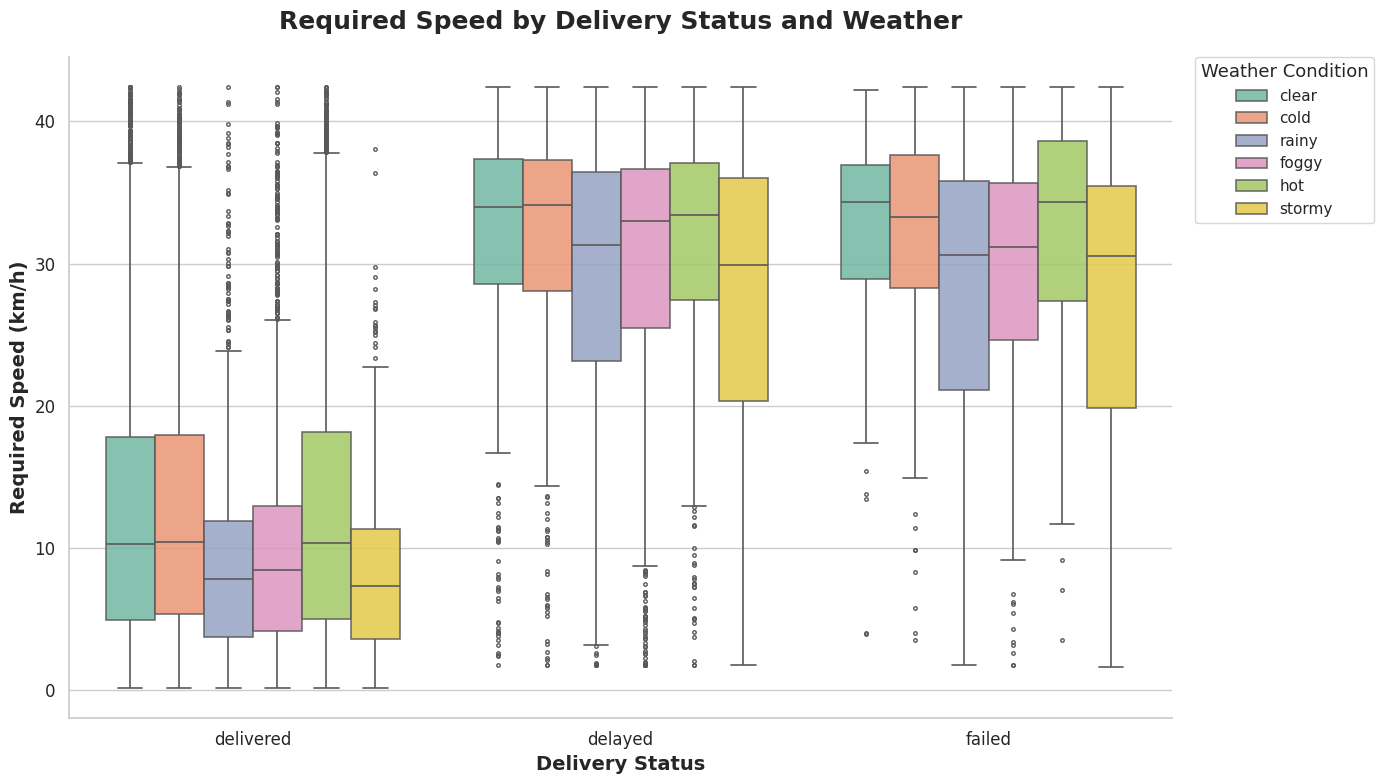

In [41]:



bad_weather = ['stormy', 'rainy','foggy']

small_vehicles = ['bikes', 'ev bike','scooters']

X['high_risk_weather_vehicles']= np.where(
    (X['weather_condition'].isin(bad_weather) & X['vehicle_type'].isin(small_vehicles)),
    1,0
    
)





X['required_speed_kmh'] = X['distance_km']/(X['expected_time_hours'] + 0.001)




X['fragile_in_bad_weather'] = np.where(

    (X['package_type'] == 'fragile items') & (X['weather_condition'].isin(bad_weather)),
    1,0
    
)


print("Feature Enginering erfolgreich beendet")
print("\nHigh Risk Weather & Vehicles:\n")
print((X['high_risk_weather_vehicles'].value_counts(normalize=True)*100).round(2))



print("\n Fragile in bad Weather\n")
print((X['fragile_in_bad_weather'].value_counts(normalize=True)*100).round(2))


print("\n Required Speed KMH \n")
print((X['required_speed_kmh'].describe()))


X['delivery_status'] = df['delivery_status']


plt.clf() 
sns.set_theme(style='whitegrid')

plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data= X, 
    x='delivery_status', 
    y='required_speed_kmh', 
    hue='weather_condition',
    palette='Set2', 
    fliersize=2.5,   
    linewidth=1.2,
    boxprops=dict(alpha=0.85) 
)

sns.despine()

plt.legend(
    title='Weather Condition', 
    title_fontsize=13,
    fontsize=11,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.title('Required Speed by Delivery Status and Weather', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Delivery Status', fontsize=14, fontweight='bold')
plt.ylabel('Required Speed (km/h)', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

## 12.The Delivery Gap & Customer Satisfaction
To prove that wrong time estimates hurt our business, I calculated the "Time Gap" (Real Delivery Time minus Expected Time). The following visualization clearly shows that customer ratings drop significantly not only when a package is late, but also when it arrives too early!

gap_category
Too Early    16288
On Time       4752
Too Late      3960
Name: count, dtype: int64
Average star rating per category:
gap_category
On Time      3.05
Too Early    4.21
Too Late     2.19
Name: delivery_rating, dtype: float64
------------------------------

Detailed star rating distribution for packages that arrived 'too early':
zu_frueh_sterne


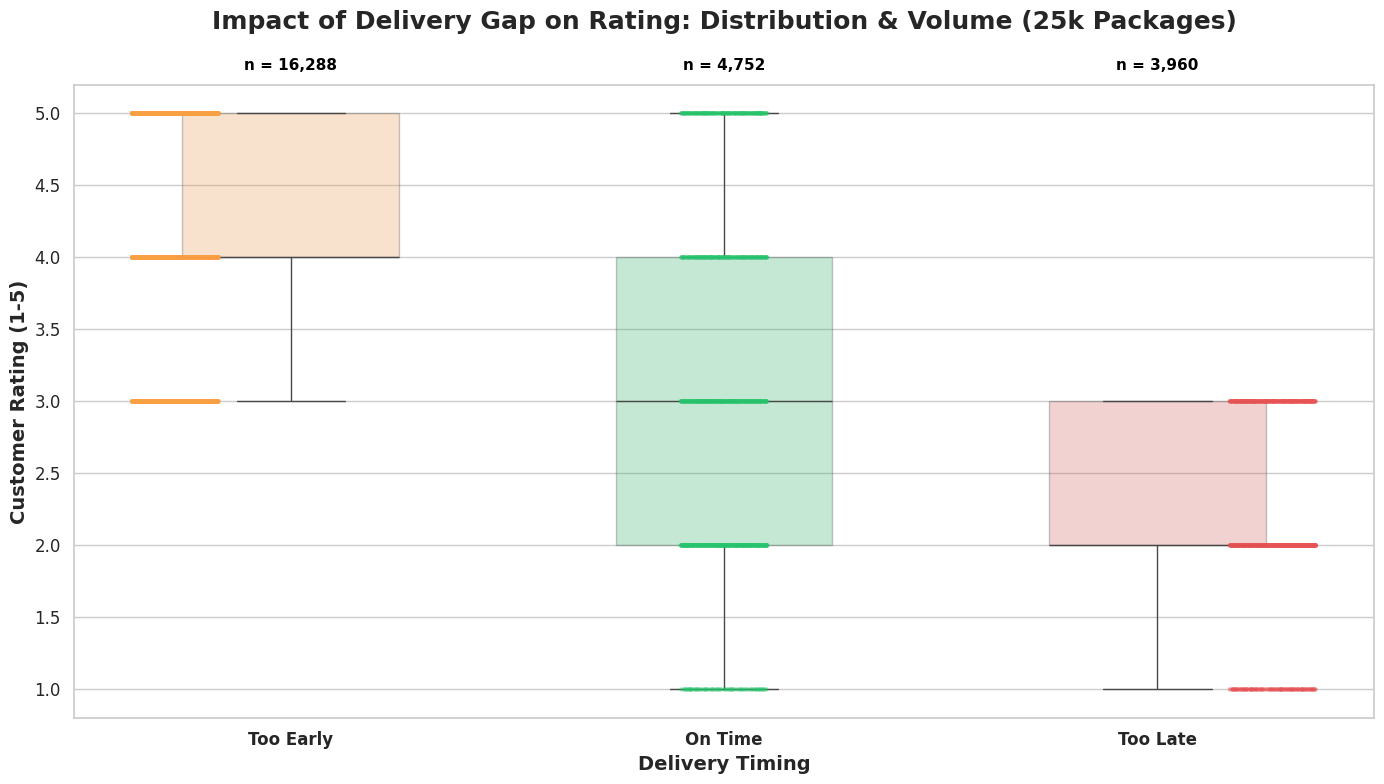

In [34]:
df['time_gap'] = df['delivery_time_hours'] - df['expected_time_hours']

conditions = [
    (df['time_gap'] < -1.0),
    (df['time_gap'] > 1.0 )
]

choices = ['Too Early', 'Too Late']
df['gap_category'] = np.select(conditions, choices, default='On Time')

print(df['gap_category'].value_counts())
print("Average star rating per category:")
durchschnitt = df.groupby('gap_category')['delivery_rating'].mean().round(2)
print(durchschnitt)

print("-" * 30)

print("\nDetailed star rating distribution for packages that arrived 'too early':")
zu_frueh_sterne = df[df['gap_category'] == 'Too Early']['delivery_rating'].value_counts().sort_index()
print('zu_frueh_sterne')


counts = df['gap_category'].value_counts()
n_too_early = counts.get('Too Early', 0)
n_on_time = counts.get('On Time', 0)
n_too_late = counts.get('Too Late', 0)

sns.set_theme(style='whitegrid')
palette_colors = {'Too Early': '#FF9F43', 'On Time': '#28C76F', 'Too Late': '#EA5455'}

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df, 
    x='gap_category', 
    y='delivery_rating', 
    order=['Too Early', 'On Time', 'Too Late'],
    palette=palette_colors,
    showfliers=False,  
    width=0.5,
    boxprops=dict(alpha=0.3) 
)

sns.stripplot(
    data=df, 
    x='gap_category', 
    y='delivery_rating', 
    order=['Too Early', 'On Time', 'Too Late'],
    palette=palette_colors,
    size=3,
    alpha=0.1, 
    jitter=0.3,
    linewidth=0,
    dodge=True
)

plt.title('Impact of Delivery Gap on Rating: Distribution & Volume (25k Packages)', fontsize=18, fontweight='bold', pad=40)
plt.xlabel('Delivery Timing', fontsize=14, fontweight='bold')
plt.ylabel('Customer Rating (1-5)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)

ax = plt.gca()
text_props = dict(fontsize=11, color='black', fontweight='bold', ha='center', backgroundcolor='#FFFFFF')
# Wir benutzen eine kleine Toleranz (e.g., 5.3), damit der Text über dem y-Achsen-Limit steht
ax.text(0, 5.3, f'n = {n_too_early:,}', **text_props)
ax.text(1, 5.3, f'n = {n_on_time:,}', **text_props)
ax.text(2, 5.3, f'n = {n_too_late:,}', **text_props)

plt.tight_layout()
plt.show()

## 13. Prevent Data Leakage & Train-Test Split
Before splitting the data, I need to drop columns like `delayed`, `delivery_rating`, and `delivery_time_hours`. These are "target leaks" because, in a real-world scenario, we wouldn't know the rating or the exact delivery time before the delivery is actually completed. Afterwards, I will perform a stratified train-test split to maintain the class distribution.

In [17]:


leakage_columns=['delivery_status', 'delayed', 'delivery_rating','delivery_time_hours']
X = X.drop(columns=leakage_columns, errors='ignore')

X_train, X_test, y_train, y_test  = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify= y_encoded
)



print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (20000, 13)
X_test: (5000, 13)


## 14. Identify Numeric and Categorical Features
Before building the preprocessing pipeline, I need to separate the numerical features from the categorical ones. Numerical data will typically be imputed and scaled, while categorical data needs to be one-hot encoded. Separating them dynamically by data type is much safer than hardcoding column names.

In [18]:


numeric_features = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()



print("Numeric features:", numeric_features)
print("Categorical_features", categorical_features)

Numeric features: ['distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost', 'high_risk_weather_vehicles', 'required_speed_kmh', 'fragile_in_bad_weather']
Categorical_features ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']


## 15. Build Preprocessing Pipeline
To prevent data leakage and ensure our workflow is easily reproducible, I am building a scikit-learn `Pipeline` and `ColumnTransformer`. 
- **Numerical Features:** Missing values will be imputed using the median, and the data will be standardized using `StandardScaler`.
- **Categorical Features:** Missing values will be filled with the most frequent category, and then transformed into binary columns using `OneHotEncoder`. The `handle_unknown="ignore"` parameter ensures the pipeline won't crash if it encounters unseen categories in the test set.

In [19]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer,categorical_features)
])

## 16. Train and Evaluate: Logistic Regression
Now it is time to build the full modeling pipeline. I am combining the preprocessing steps with a `LogisticRegression` classifier. Crucially, I am setting `class_weight="balanced"` because our target variable has a severe class imbalance. This ensures the model pays enough attention to the minority classes (like 'failed' deliveries).

Logistic Regression Accuracy 0.7712

Classifiction Report: 

              precision    recall  f1-score   support

     delayed       0.59      0.50      0.54      1068
   delivered       0.98      0.87      0.92      3666
      failed       0.16      0.54      0.25       266

    accuracy                           0.77      5000
   macro avg       0.58      0.63      0.57      5000
weighted avg       0.86      0.77      0.81      5000



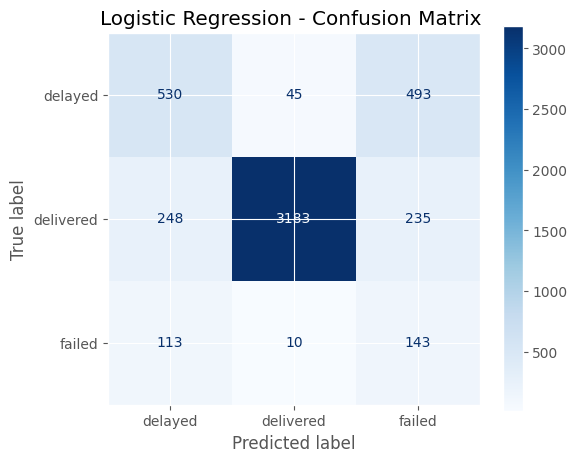

In [20]:

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
    
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)


print("Logistic Regression Accuracy", accuracy_score(y_test, y_pred_logreg) )
print("\nClassifiction Report: \n")
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_))



fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logreg,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    ax=ax
)


plt.title("Logistic Regression - Confusion Matrix ")
plt.show()


## 17. Train and Evaluate: Random Forest
To see if a more complex, tree-based ensemble model performs better, I am training a `RandomForestClassifier`. I've set specific hyperparameters like `max_depth` and `min_samples_split` to prevent the trees from overfitting to the training data. As with the Logistic Regression, `class_weight="balanced"` is essential here to handle our imbalanced classes.

In [21]:


rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report: \n")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.8248

Classification Report: 

              precision    recall  f1-score   support

     delayed       0.58      0.86      0.69      1068
   delivered       0.99      0.86      0.92      3666
      failed       0.18      0.14      0.16       266

    accuracy                           0.82      5000
   macro avg       0.58      0.62      0.59      5000
weighted avg       0.86      0.82      0.83      5000



## 18. Handling Imbalance with SMOTE
Instead of just adjusting class weights, another powerful approach for imbalanced datasets is SMOTE (Synthetic Minority Over-sampling Technique). It generates synthetic samples for the minority classes. I am strictly using the `Pipeline` from the `imblearn` library, which ensures that SMOTE is only applied to the training data, completely avoiding data leakage into the test set.

In [22]:


from imblearn.pipeline import Pipeline as ImbPipeline 
from imblearn.over_sampling import SMOTE 


rf_smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ))
])



rf_smote_pipeline.fit(X_train, y_train)
y_pred_rf_smote = rf_smote_pipeline.predict(X_test)



print("Random Forest (SMOTE) Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print ("\Classification Report:\n ")
print(classification_report(y_test, y_pred_rf_smote, target_names=label_encoder.classes_))

Random Forest (SMOTE) Accuracy: 0.8484
\Classification Report:
 
              precision    recall  f1-score   support

     delayed       0.63      0.82      0.71      1068
   delivered       0.95      0.91      0.93      3666
      failed       0.14      0.03      0.05       266

    accuracy                           0.85      5000
   macro avg       0.57      0.59      0.57      5000
weighted avg       0.84      0.85      0.84      5000



## 19. Train and Evaluate: XGBoost with SMOTE
For the final model, I am using `XGBClassifier` (eXtreme Gradient Boosting), which is highly optimized and widely considered state-of-the-art for tabular data. I am keeping the SMOTE pipeline to handle the class imbalance and passing specific hyperparameters like `learning_rate` and `max_depth` to control the learning process.

In [23]:


from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline 
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score


xgb_smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    ))
])


xgb_smote_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_smote_pipeline.predict(X_test)





print("XGBoost (SMOTE) Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))

XGBoost (SMOTE) Accuracy: 0.8502

Classification Report:

              precision    recall  f1-score   support

     delayed       0.66      0.75      0.70      1068
   delivered       0.91      0.94      0.93      3666
      failed       0.12      0.01      0.02       266

    accuracy                           0.85      5000
   macro avg       0.57      0.57      0.55      5000
weighted avg       0.82      0.85      0.83      5000



## 20. Random Forest with Custom Class Weights
Instead of generating synthetic data with SMOTE, another powerful technique is to manually penalize the model for missing the minority class. By defining custom class weights (`{0: 4, 1: 1, 2: 20}`), I am forcing the algorithm to pay extreme attention to class 2 ('failed' deliveries) by penalizing mistakes on this class 20 times more than mistakes on class 1.

In [24]:
# 21. Random Forest mit Custom Class Weights (Ohne SMOTE)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


custom_weights = {0: 4, 1: 1, 2: 20} 

rf_weighted_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=10,     
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42,
        class_weight=custom_weights
    ))
])

rf_weighted_pipeline.fit(X_train, y_train)

y_pred_rf_weighted = rf_weighted_pipeline.predict(X_test)

print("Random Forest (Custom Weights) Accuracy:", round(accuracy_score(y_test, y_pred_rf_weighted), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_weighted, target_names=label_encoder.classes_))

Random Forest (Custom Weights) Accuracy: 0.769

Classification Report:

              precision    recall  f1-score   support

     delayed       0.57      0.55      0.56      1068
   delivered       0.99      0.85      0.92      3666
      failed       0.16      0.48      0.24       266

    accuracy                           0.77      5000
   macro avg       0.57      0.63      0.57      5000
weighted avg       0.85      0.77      0.80      5000



# Final Business Report: How to Improve Our Delivery

I analyzed the delivery data and built Machine Learning models to predict failed deliveries. Here are my clear ideas for the management. Our main goals are: lower costs, better data, and happier customers.

## 1. What the Data Tells Us (Key Discoveries)

* **Distance is not the problem, but it controls the price:** The data shows that packages fail on short trips and long trips. Distance is not the reason for failures; the problem is bad handling or routing. However, the price is *only* calculated by distance (1.0 correlation). We do not charge extra for hard work, like driving in bad weather.
* *** **The ETA Forecasting Problem (The Delivery Gap):** The data reveals a massive flaw in our system: Over 65% of all packages arrive *much earlier* than expected. This massive gap proves our internal time forecasting is completely inaccurate. Arriving "too early" is actually a hidden logistical nightmare:
    * **For the Customer:** They are often not at home or, for larger deliveries (like pallets), lack the personnel and equipment ready to unload. This creates security risks (theft/weather) and lowers satisfaction.
    * **For the Company:** It causes warehouse chaos (goods arriving before space is cleared) and reveals highly inefficient route planning (trucks are driving with too much slack and could carry more).
    * **For the Driver:** If a customer cannot accept an early package, the driver faces double work (re-loading and re-delivering the next day), which wastes time, fuel, and ruins their success metrics.
    * **Conclusion:** We desperately need smarter ETA predictions to optimize our warehouse operations, route efficiency, and driver schedules accurately.
* **High risk with bad weather and small vehicles:** I created new data features and found a big problem: Small vehicles (scooters, bikes) driving in bad weather (storm, rain) fail very often. 
* **Failures are rare:** Only about 5% of all deliveries fail. Because it happens so rarely, our computer models need richer and better data to predict it perfectly.

## 2. What We Should Do (Strategic Recommendations)

To make our delivery partners better and stop losing packages, we should do these four things:

1. **Change the prices:** Do not only look at the distance. Make the price higher when the weather is bad or the package is very heavy. This helps to cover the extra risk.
2. **Choose vehicles smarter:** When there is a storm or heavy rain, do not use bikes or scooters. The system should automatically give these packages to safer vehicles like vans or trucks. 
3. **Fix the expected time:** We can use my trained XGBoost model to predict a delay *before* the driver even starts. We can tell the customer early if the package will be late.
4. **Collect better data:** To really optimize our logistics, we must collect more details. We strongly recommend:
    * **Real-time GPS Tracking:** To see exactly where a package gets lost on the road.
    * **Scan Checkpoints:** To scan the package at every stop and warehouse.
    * **Operational Logs:** To write down if a vehicle breaks down or if a driver makes a mistake.

**Final Conclusion:** If we upgrade our data collection (like GPS and Scans) and use smart Machine Learning models, we will lose fewer packages, save a lot of money, and give our customers a much better service.